In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [4]:
df = pd.read_excel(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\Data\Data_BBCA_2015_sampai_sekarang.xlsx")
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-02 00:00:00,2171.209473,2179.418204,2158.896375,2179.418204,29302500
3,2015-01-05 00:00:00,2167.105957,2167.105957,2154.792855,2158.897222,25434500
4,2015-01-06 00:00:00,2150.688477,2167.105946,2134.271007,2134.271007,48681500


In [5]:
df = df.drop(df.index[0:2])
df.head(10)

,Price,Close,High,Low,Open,Volume
2,2015-01-02 00:00:00,2171.209473,2179.418204,2158.896375,2179.418204,29302500
3,2015-01-05 00:00:00,2167.105957,2167.105957,2154.792855,2158.897222,25434500
4,2015-01-06 00:00:00,2150.688477,2167.105946,2134.271007,2134.271007,48681500
5,2015-01-07 00:00:00,2154.791992,2167.105089,2142.478895,2142.478895,40334000
6,2015-01-08 00:00:00,2130.166504,2158.897073,2130.166504,2154.792706,54457000
7,2015-01-09 00:00:00,2121.956787,2146.582978,2121.956787,2138.374248,108957500
8,2015-01-12 00:00:00,2134.270508,2134.270508,2101.435577,2121.957409,81651000
9,2015-01-13 00:00:00,2134.270508,2142.479241,2130.166141,2142.479241,36024000
10,2015-01-14 00:00:00,2121.956787,2138.374248,2121.956787,2138.374248,29728000
11,2015-01-15 00:00:00,2126.061279,2142.478741,2126.061279,2126.061279,27580500


In [6]:
df.isnull().sum()

Price     0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2653 entries, 2 to 2654
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   2653 non-null   object
 1   Close   2653 non-null   object
 2   High    2653 non-null   object
 3   Low     2653 non-null   object
 4   Open    2653 non-null   object
 5   Volume  2653 non-null   object
dtypes: object(6)
memory usage: 124.5+ KB


In [8]:
df['Price'] = pd.to_datetime(df['Price'])

df = df.rename(columns={'Price': 'Date'})

df = df.sort_values("Date")
df.head()

,Date,Close,High,Low,Open,Volume
2,2015-01-02,2171.209473,2179.418204,2158.896375,2179.418204,29302500
3,2015-01-05,2167.105957,2167.105957,2154.792855,2158.897222,25434500
4,2015-01-06,2150.688477,2167.105946,2134.271007,2134.271007,48681500
5,2015-01-07,2154.791992,2167.105089,2142.478895,2142.478895,40334000
6,2015-01-08,2130.166504,2158.897073,2130.166504,2154.792706,54457000


In [9]:
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    df[col] = (
        df[col]
        .astype(str)                     # pastikan string
        .str.replace(',', '', regex=False)  # hapus koma ribuan
        .str.replace(' ', '', regex=False)  # hapus spasi
        .astype(float)                   # ubah ke float
    )

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2653 entries, 2 to 2654
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2653 non-null   datetime64[ns]
 1   Close   2653 non-null   float64       
 2   High    2653 non-null   float64       
 3   Low     2653 non-null   float64       
 4   Open    2653 non-null   float64       
 5   Volume  2653 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 124.5 KB


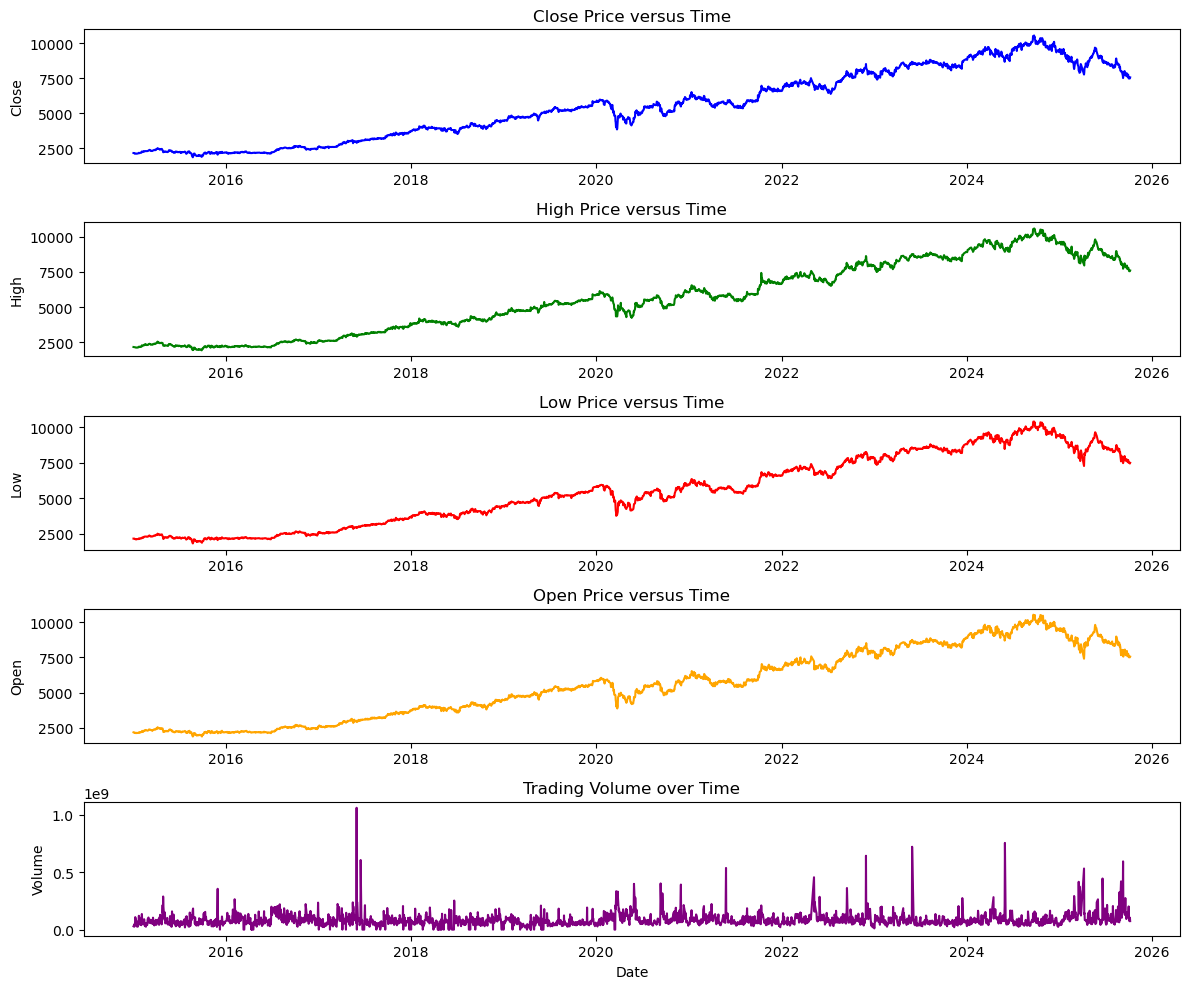

In [11]:
# Atur ukuran figure
plt.figure(figsize=(12, 10))

# Plot Close
plt.subplot(5, 1, 1)
plt.plot(df['Date'], df['Close'], color='blue')
plt.title('Close Price versus Time')
plt.ylabel('Close')

# Plot High
plt.subplot(5, 1, 2)
plt.plot(df['Date'], df['High'], color='green')
plt.title('High Price versus Time')
plt.ylabel('High')

# Plot Low
plt.subplot(5, 1, 3)
plt.plot(df['Date'], df['Low'], color='red')
plt.title('Low Price versus Time')
plt.ylabel('Low')

# Plot Open
plt.subplot(5, 1, 4)
plt.plot(df['Date'], df['Open'], color='orange')
plt.title('Open Price versus Time')
plt.ylabel('Open')

# Plot Volume
plt.subplot(5, 1, 5)
plt.plot(df['Date'], df['Volume'], color='purple')
plt.title('Trading Volume over Time')
plt.ylabel('Volume')
plt.xlabel('Date')

# Tata letak agar tidak saling tumpuk
plt.tight_layout()
plt.show()


In [12]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
target_col = 'Close'
target_idx = features.index(target_col)

In [13]:
# --- 2️⃣ Split dulu (biar tidak ada data leakage)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

In [14]:
# --- 3️⃣ Scaling terpisah
scaler_main = MinMaxScaler()
scaler_resid = StandardScaler()

# Fit scaler hanya pada data train
scaled_main_train = scaler_main.fit_transform(train_df[['Open','High','Low','Close','Volume']])

# Transform data test pakai scaler yang sudah fit dari train
scaled_main_test = scaler_main.transform(test_df[['Open','High','Low','Close','Volume']])

# Gabungkan main + residual
scaled_train = np.concatenate([scaled_main_train], axis=1)
scaled_test  = np.concatenate([scaled_main_test], axis=1)

# Gabungkan kembali (optional, biar gampang buat sliding window)
scaled_data = np.vstack([scaled_train, scaled_test])

In [15]:
# --- 4️⃣ Buat window time series (lookback 60)
lookback = 60
X, y = [], []
for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i-lookback:i])
    y.append(scaled_data[i, target_idx])

X, y = np.array(X), np.array(y)

In [16]:
# --- 5️⃣ Split ulang X/y sesuai proporsi train-test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target yang dipakai:", target_col)

X shape: (2593, 60, 5)
y shape: (2593,)
Target yang dipakai: Close


In [17]:
#Bangun Model LSTM

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dense(1)  # output 1 nilai Close
])

model.compile(optimizer='adam', loss='mse')
model.summary()

D:\Terminal\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 128)             │          68,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 120,385 (470.25 KB)

 Trainable params: 120,257 (469.75 KB)

 Non-trainable params: 128 (512.00 B)

In [18]:
#Latih Model 

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,     # berhenti jika 5 epoch berturut-turut val_loss tidak membaik
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - loss: 0.2904 - val_loss: 0.8081
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0608 - val_loss: 0.7826
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0303 - val_loss: 0.6380
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 0.0278 - val_loss: 0.6106
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0203 - val_loss: 0.5169
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 0.0149 - val_loss: 0.4437
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0123 - val_loss: 0.2692
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0113 - val_loss: 0.2150
Epoch 9/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0094 - val_loss: 0.1483
Epoch 10/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0084 - val_loss: 0.0409
Epoch 11/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 0.0079 - val_loss: 0.0870
Epoch 12/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/st

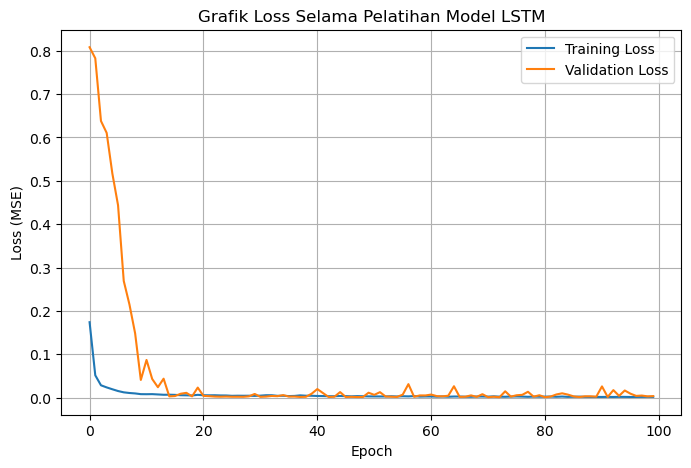

In [19]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss Selama Pelatihan Model LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
predictions = model.predict(X_test)

# --- inverse transform pakai scaler_main karena target = Close
y_test_full = np.zeros((len(y_test), 5))
y_pred_full = np.zeros((len(predictions), 5))

# isi hanya kolom ke-3 (Close)
y_test_full[:, 3] = y_test
y_pred_full[:, 3] = predictions[:, 0]

# inverse pakai scaler_main
y_test_inv = scaler_main.inverse_transform(y_test_full)[:, 3]
y_pred_inv = scaler_main.inverse_transform(y_pred_full)[:, 3]


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step


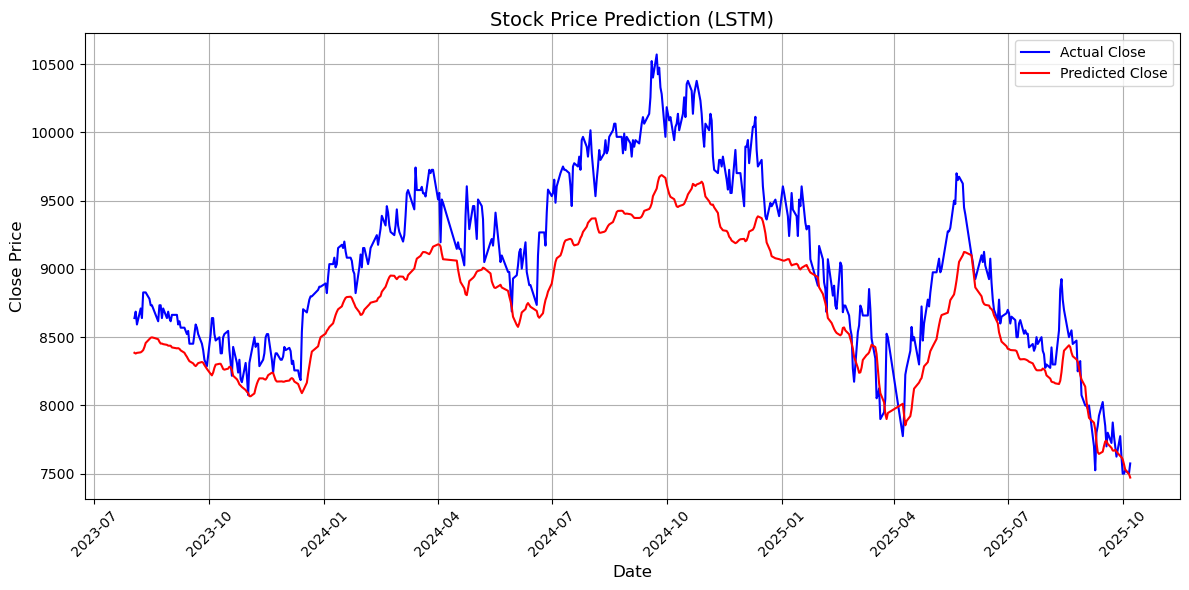

In [21]:
plt.figure(figsize=(12,6))

# Ambil tanggal yang sesuai dengan y_test
dates_test = df['Date'].iloc[-len(y_test_inv):]

plt.plot(dates_test, y_test_inv, label='Actual Close', color='blue')
plt.plot(dates_test, y_pred_inv, label='Predicted Close', color='red')

plt.title('Stock Price Prediction (LSTM)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [22]:
import pandas as pd

# Buat DataFrame untuk prediksi
df_pred = pd.DataFrame({
    'Date': dates_test,
    'Predicted_Close': y_pred_inv
})

# Simpan ke CSV
df_pred.to_csv('predicted_close_LSTM.csv', index=False)
print("CSV prediksi berhasil dibuat!")


CSV prediksi berhasil dibuat!


In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# pastikan y_test_inv dan y_pred_inv adalah numpy array
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100
print(f"MAPE: {mape:.2f}%")

RMSE: 403.19
MAE: 347.17
MAPE: 3.73%


In [24]:
rmse_percent = (rmse / df['Close'].mean()) * 100
mae_percent = (mae / df['Close'].mean()) * 100
print(f"RMSE%: {rmse_percent:.2f}% | MAE%: {mae_percent:.2f}%")

RMSE%: 7.31% | MAE%: 6.29%


### Prediksi 30 bulan ke depan

In [26]:
future_days = 30
lookback = 60  # pastikan sesuai
last_sequence = scaled_data[-lookback:]  # 60 data terakhir
future_predictions = []

current_seq = last_sequence.copy()

for _ in range(future_days):
    # prediksi Close
    pred_close = model.predict(current_seq.reshape(1, lookback, scaled_data.shape[1]))
    future_predictions.append(pred_close[0, 0])
    
    # buat row baru untuk geser window, pertahankan struktur 9 kolom
    next_row = current_seq[-1].copy()  # copy data terakhir
    next_row[3] = pred_close[0, 0]    # update Close
    # residual tetap dummy (misal ambil nilai terakhir atau bisa dihitung jika ada model residual)
    # next_row[5:9] tetap = current_seq[-1,5:9]
    
    # geser window
    current_seq = np.vstack([current_seq[1:], next_row])

# kembalikan ke skala asli untuk Close
future_full = np.zeros((len(future_predictions), scaled_data.shape[1]))
future_full[:, 3] = future_predictions  # hanya Close
future_pred_inv = scaler_main.inverse_transform(future_full[:, :5])[:, 3]  # Close asli


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━

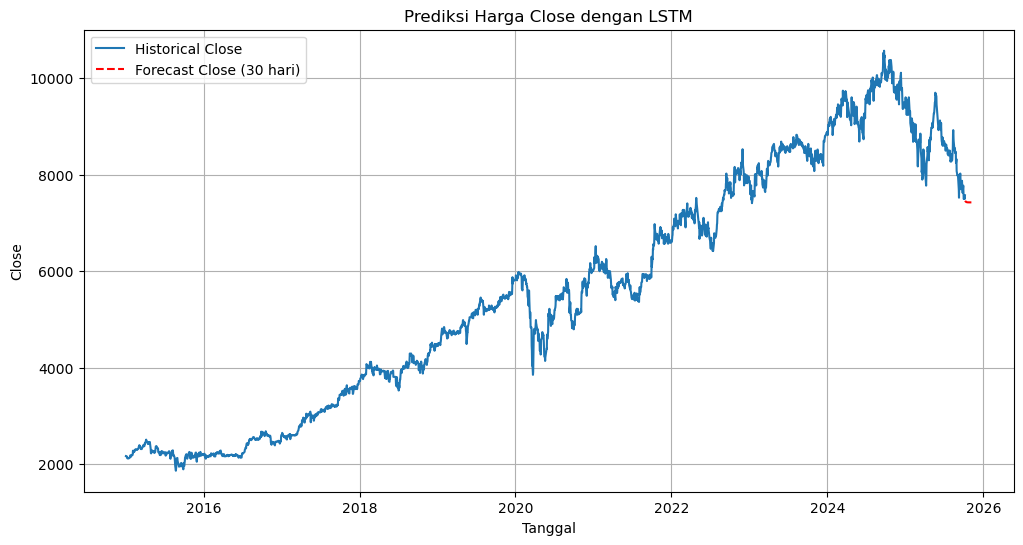

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# buat range tanggal untuk forecast
last_date = df['Date'].iloc[-1]  # tanggal terakhir historical
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=future_days)

# gabungkan historical + forecast untuk plotting
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Historical Close')
plt.plot(future_dates, future_pred_inv, label='Forecast Close (30 hari)', color='red', linestyle='--')
plt.title('Prediksi Harga Close dengan LSTM')
plt.xlabel('Tanggal')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.show()


In [54]:
lstm = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\predicted_close_LSTM.csv")
lstmsentimenarima = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\predicted_close_LSTM_AnalisisSentimen_ARIMA.csv")
lstmARIMA = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\predicted_close_LSTM_ARIMA.csv")
lstmsentimen = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\predicted_close_LSTM_sentimen.csv")

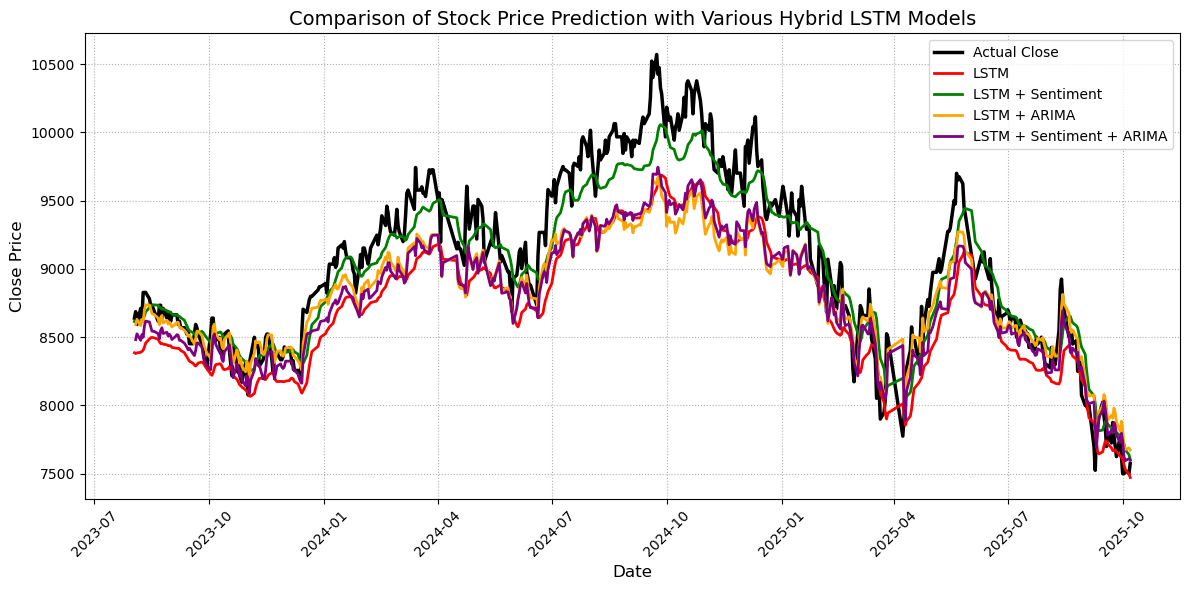

In [56]:
# --- 2. Pastikan kolom tanggal terbaca sebagai datetime ---
for df_pred in [lstm, lstmsentimenarima, lstmARIMA, lstmsentimen]:
    df_pred['Date'] = pd.to_datetime(df_pred['Date'])

# --- 3. Plot semua model pada satu grafik ---
plt.figure(figsize=(12,6))

# Data aktual
plt.plot(df['Date'].iloc[-len(y_test_inv):], y_test_inv, 
         label='Actual Close', color='black', linewidth=2.5)

# Hasil prediksi tiap model (garis tebal, warna berbeda)
plt.plot(lstm['Date'], lstm['Predicted_Close'], 
         label='LSTM', color='red', linewidth=2)
plt.plot(lstmsentimen['Date'], lstmsentimen['Predicted_Close'], 
         label='LSTM + Sentiment', color='green', linewidth=2)
plt.plot(lstmARIMA['Date'], lstmARIMA['Predicted_Close'], 
         label='LSTM + ARIMA', color='orange', linewidth=2)
plt.plot(lstmsentimenarima['Date'], lstmsentimenarima['Predicted_Close'], 
         label='LSTM + Sentiment + ARIMA', color='purple', linewidth=2)

# --- 4. Format tampilan ---
plt.title('Comparison of Stock Price Prediction with Various Hybrid LSTM Models', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()